# Proyek Klasifikasi Gambar: [Animals-10]
- **Nama:** [David Sebastian Sutandy]
- **Email:** [Input Email]
- **ID Dicoding:** [Input Username]

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import files


## Data Preparation

### Data Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -q "/content/drive/MyDrive/hewan.zip" -d /content/

Mounted at /content/drive


### Data Preprocessing

#### Split Dataset
Dataset dipisah menjadi train/val/test agar evaluasi akhir benar-benar menggunakan data yang belum pernah dilihat model (menghindari data leakage).

In [3]:
!mkdir /content/animals10
!mv /content/cane /content/animals10/
!mv /content/cavallo /content/animals10/
!mv /content/gallina /content/animals10/
!mv /content/gatto /content/animals10/
!mv /content/mucca /content/animals10/
!mv /content/pecora /content/animals10/
!mv /content/scoiattolo /content/animals10/
!mv /content/farfalla /content/animals10/
!mv /content/ragno /content/animals10/
!mv /content/elefante /content/animals10/


In [4]:
!pip install split-folders -q
import splitfolders

splitfolders.ratio(
    "/content/animals10",
    output="/content/animals10_split",
    seed=123,
    ratio=(.7, .15, .15)
)

train_dir = "/content/animals10_split/train"
val_dir   = "/content/animals10_split/val"
test_dir  = "/content/animals10_split/test"


Copying files: 26179 files [00:05, 4366.90 files/s]


#### Cek Resolusi Gambar

In [5]:
from collections import Counter
from PIL import Image

dataset_dir = "/content/animals10"

resolutions = []

for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        file_path = os.path.join(class_path, file)

        try:
            with Image.open(file_path) as img:
                resolutions.append(img.size)
        except:
            print("Tidak bisa membuka file:", file_path)

res_count = Counter(resolutions)

print("Daftar Resolusi Gambar")
for size, count in res_count.items():
    print(f"{size}: {count} gambar")

print("\nTotal gambar:", len(resolutions))
print("Resolusi unik:", len(res_count))


Daftar Resolusi Gambar
(200, 300): 362 gambar
(300, 290): 38 gambar
(300, 246): 50 gambar
(300, 225): 4397 gambar
(300, 166): 28 gambar
(300, 200): 3281 gambar
(300, 299): 46 gambar
(300, 226): 240 gambar
(300, 232): 99 gambar
(291, 300): 32 gambar
(283, 178): 1 gambar
(300, 169): 1048 gambar
(252, 300): 21 gambar
(300, 300): 1192 gambar
(225, 300): 490 gambar
(300, 223): 104 gambar
(300, 229): 64 gambar
(300, 266): 49 gambar
(300, 267): 67 gambar
(300, 221): 299 gambar
(300, 279): 24 gambar
(276, 300): 28 gambar
(300, 201): 288 gambar
(278, 300): 29 gambar
(300, 100): 5 gambar
(300, 224): 110 gambar
(300, 271): 52 gambar
(300, 197): 108 gambar
(300, 283): 59 gambar
(258, 300): 28 gambar
(272, 300): 26 gambar
(300, 139): 6 gambar
(300, 180): 89 gambar
(281, 300): 17 gambar
(300, 220): 119 gambar
(300, 257): 53 gambar
(247, 300): 30 gambar
(220, 300): 29 gambar
(300, 239): 50 gambar
(300, 199): 586 gambar
(259, 300): 13 gambar
(204, 267): 2 gambar
(208, 300): 15 gambar
(170, 300): 14 ga

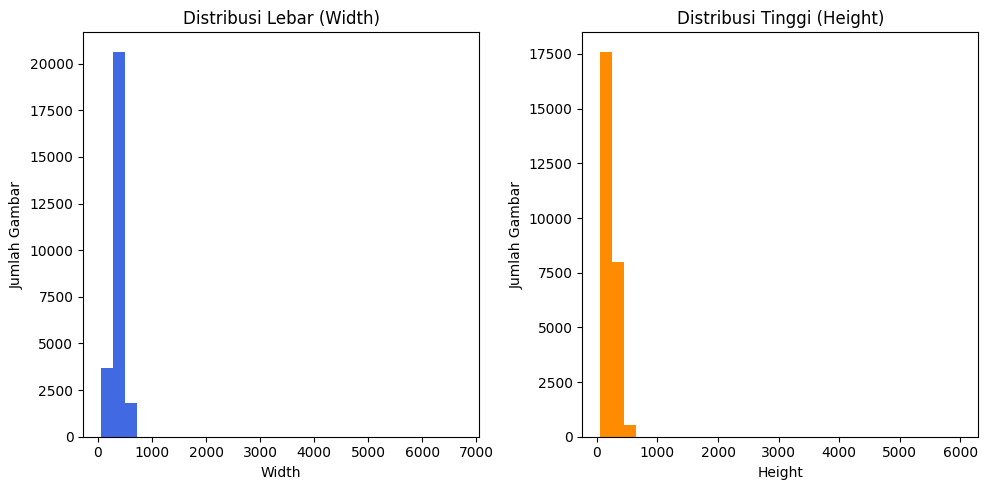

In [6]:
widths = [w for (w, h) in resolutions]
heights = [h for (w, h) in resolutions]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=30, color='royalblue')
plt.title("Distribusi Lebar (Width)")
plt.xlabel("Width")
plt.ylabel("Jumlah Gambar")

plt.subplot(1, 2, 2)
plt.hist(heights, bins=30, color='darkorange')
plt.title("Distribusi Tinggi (Height)")
plt.xlabel("Height")
plt.ylabel("Jumlah Gambar")

plt.tight_layout()
plt.show()


#### Tampilkan Contoh Gambar per Kelas

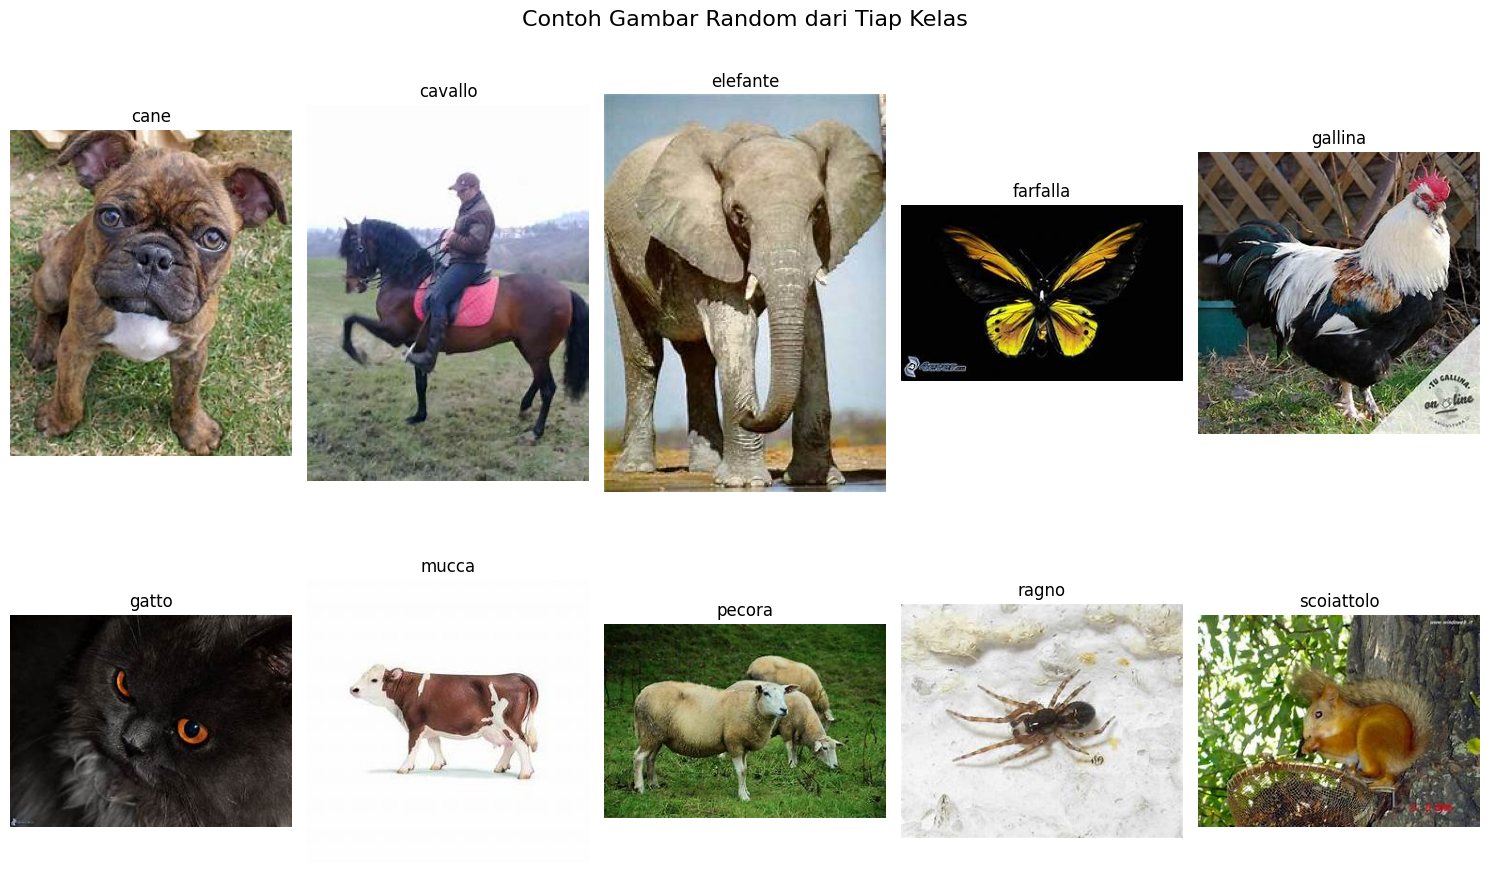

In [7]:
import random

classes = sorted(os.listdir(dataset_dir))

plt.figure(figsize=(15, 10))

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_dir, cls)

    if not os.path.isdir(class_path):
        continue

    files_in_class = os.listdir(class_path)
    img_name = random.choice(files_in_class)
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Contoh Gambar Random dari Tiap Kelas", fontsize=16)
plt.tight_layout()
plt.show()


#### Load Dataset (train/val/test terpisah)

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 10
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
print("Class names:", class_names)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


Found 18322 files belonging to 10 classes.
Found 3922 files belonging to 10 classes.
Found 3935 files belonging to 10 classes.
Class names: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


#### Class Weight (mengatasi ketidakseimbangan kelas)

In [9]:
class_counts = [len(os.listdir(os.path.join(train_dir, c))) for c in class_names]
total = sum(class_counts)
class_weight = {i: total / (NUM_CLASSES * cnt) for i, cnt in enumerate(class_counts)}
print("Class weights:", class_weight)


Class weights: {0: 0.5382491186839012, 1: 0.9979302832244009, 2: 1.8104743083003954, 3: 1.2396481732070366, 4: 0.845110701107011, 5: 1.5700085689802914, 6: 1.4029096477794794, 7: 1.4381475667189954, 8: 0.5430349733254297, 9: 1.4061396776669224}


#### Augmentasi Data

In [10]:
data_aug = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")


## Modelling

## MobileNetV2

In [11]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_aug(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### Callbacks

In [13]:
class StopAtValAccuracy(tf.keras.callbacks.Callback):
    def __init__(self, target=0.95):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get("val_accuracy")
        if val_acc is not None and val_acc >= self.target:
            print(f"\nVal Accuracy {val_acc:.4f} >= {self.target*100:.1f}%. Training dihentikan otomatis.")
            self.model.stop_training = True

callbacks = [
    StopAtValAccuracy(0.95),
    tf.keras.callbacks.ModelCheckpoint("best_mobilenetv2.h5", save_best_only=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
]


#### Training Tahap 1 (freeze base_model, hanya train head)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks
)


Epoch 1/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7321 - loss: 1.2106


Val Accuracy 0.9536 >= 95.0%. Training dihentikan otomatis.
573/573 ━━━━━━━━━━━━━━━━━━━━ 1368s 2s/step - accuracy: 0.8205 - loss: 1.0030 - val_accuracy: 0.9536 - val_loss: 0.6773 - learning_rate: 0.0010


#### Training Tahap 2 (fine-tuning, unfreeze sebagian base_model)

In [15]:
base_model.trainable = True
for layer in base_model.layers[:80]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weight,
    callbacks=callbacks
)


Epoch 1/25
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8149 - loss: 1.0100


Val Accuracy 0.9582 >= 95.0%. Training dihentikan otomatis.
573/573 ━━━━━━━━━━━━━━━━━━━━ 2094s 4s/step - accuracy: 0.8424 - loss: 0.9422 - val_accuracy: 0.9582 - val_loss: 0.6775 - learning_rate: 1.0000e-05


## Evaluasi dan Visualisasi

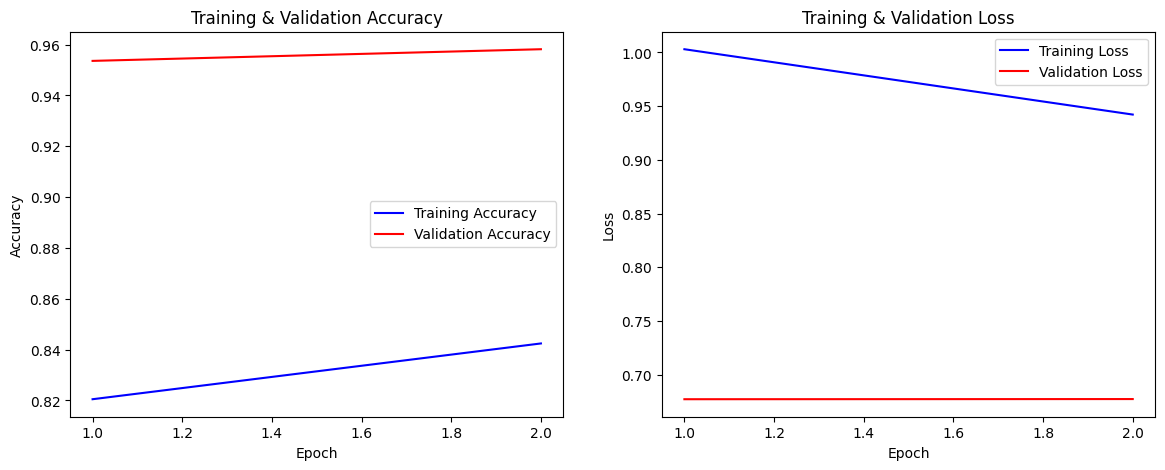

In [16]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-', label='Training Loss')
plt.plot(epochs_range, val_loss, 'r-', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

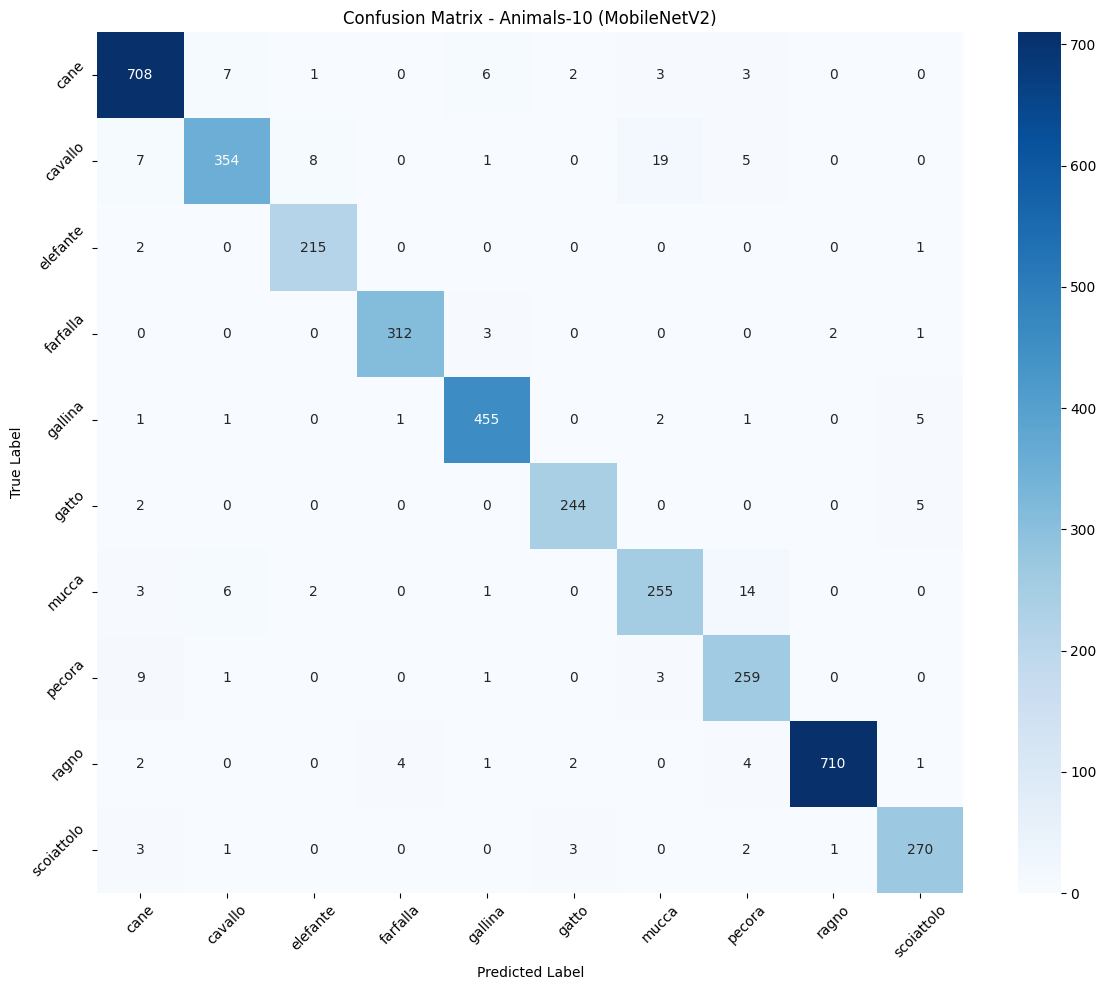

              precision    recall  f1-score   support

        cane       0.96      0.97      0.97       730
     cavallo       0.96      0.90      0.93       394
    elefante       0.95      0.99      0.97       218
    farfalla       0.98      0.98      0.98       318
     gallina       0.97      0.98      0.97       466
       gatto       0.97      0.97      0.97       251
       mucca       0.90      0.91      0.91       281
      pecora       0.90      0.95      0.92       273
       ragno       1.00      0.98      0.99       724
  scoiattolo       0.95      0.96      0.96       280

    accuracy                           0.96      3935
   macro avg       0.96      0.96      0.96      3935
weighted avg       0.96      0.96      0.96      3935

123/123 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9611 - loss: 0.6754
Akurasi Test Set: 96.11%


In [17]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Animals-10 (MobileNetV2)")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

test_loss, test_acc = model.evaluate(test_ds)
print(f"Akurasi Test Set: {test_acc*100:.2f}%")


## Konversi Model

In [18]:
model.save("mobilenetv2_animals10.keras", save_format="keras")


In [19]:
model.export("submission/saved_model")


Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135120238861136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135122681684688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120411218704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228701136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228701520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228700944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228704400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228704592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120238867664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228702288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135

In [20]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("mobilenetv2_animals10.tflite", "wb") as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmpfog0ef1d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135120228700944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228704400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228704592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120238867664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228702288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228704976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228704208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228705936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228705552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228703248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135120228

## Inference


In [21]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)


Saving pexels-photo-36879842.avif to pexels-photo-36879842.avif


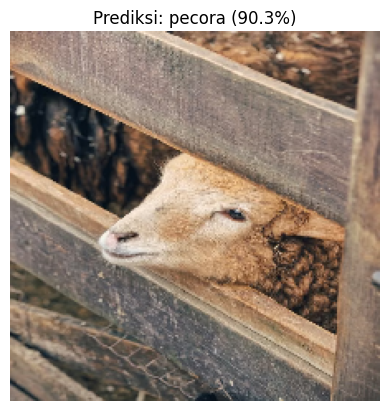

In [32]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

input_data, original_img = load_and_prepare_tflite(img_path)

interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

output_data = interpreter.get_tensor(output_details[0]['index'])
pred_idx = int(np.argmax(output_data))
pred_class = class_names[pred_idx]
confidence = float(output_data[0][pred_idx]) * 100

plt.imshow(original_img)
plt.title(f"Prediksi: {pred_class} ({confidence:.1f}%)")
plt.axis("off")
plt.show()

In [24]:
with open("label.txt", "w") as f:
    for cls in class_names:
        f.write(cls + "\n")
